# OPTIMIZING DISCOUNTS FOR MAXIMUM PROFITABILITY

# Problem Statement

#### Examine how varying discount levels impact overall profitability across different regions, product categories, and transaction volumes, in order to identify discount thresholds that lead to profit erosion and recommend optimized discount strategies that maximize profit without significantly reducing sales.

# Objective

#### To evaluate the impact of discount strategies on sales and profitability, and identify optimal discount levels that maximize profit while maintaining sales performance.

# Research Questions

#### Are there cases where high discounts do not significantly increase sales? 
#### Which regions or categories show inefficient discounting?

# Impoting Libraries

In [ ]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Statistical Analysis
from scipy import stats

# Modeling
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Warnings
import warnings
warnings.filterwarnings("Ig")


# Loading the dataset

In [7]:
df = pd.read_csv("Ecommerce_Sales_Data_2024_2025.csv")

In [8]:
df.head()

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card


# Exploratory Data Analysis

In [33]:
df.shape

(5000, 15)

In [34]:
df.dtypes

Order ID                    int64
Order Date         datetime64[ns]
Customer Name              object
Region                     object
City                       object
Category                   object
Sub-Category               object
Product Name               object
Quantity                    int64
Unit Price                  int64
Discount                    int64
Sales                     float64
Profit                    float64
Payment Mode               object
Discount_Bucket          category
dtype: object

In [35]:
df[df.duplicated()]

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode,Discount_Bucket


In [36]:
# Changing Data type
df['Order Date'] = pd.to_datetime(df['Order Date'])

In [37]:
# Selecting key columns for analysis
df_filtered = df[['Region', 'Category', 'Sub-Category', 'Discount', 'Unit Price', 'Quantity', 'Sales', 'Profit']]
df_filtered.head()

,Region,Category,Sub-Category,Discount,Unit Price,Quantity,Sales,Profit
0,South,Books,Non-Fiction,5,36294,2,68958.6,10525.09
1,North,Groceries,Rice,20,42165,1,33732.0,6299.66
2,East,Kitchen,Juicer,20,64876,4,207603.2,19850.27
3,East,Groceries,Oil,15,37320,5,158610.0,36311.02
4,West,Clothing,Kids Wear,10,50037,1,45033.3,9050.04


In [38]:
df_filtered.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Region        5000 non-null   object 
 1   Category      5000 non-null   object 
 2   Sub-Category  5000 non-null   object 
 3   Discount      5000 non-null   int64  
 4   Unit Price    5000 non-null   int64  
 5   Quantity      5000 non-null   int64  
 6   Sales         5000 non-null   float64
 7   Profit        5000 non-null   float64
dtypes: float64(2), int64(3), object(3)
memory usage: 312.6+ KB


In [39]:
# Finding null values
df_filtered.isnull().sum()

Region          0
Category        0
Sub-Category    0
Discount        0
Unit Price      0
Quantity        0
Sales           0
Profit          0
dtype: int64

In [40]:
df_filtered[['Discount', 'Unit Price', 'Quantity', 'Sales', 'Profit']].describe()

,Discount,Unit Price,Quantity,Sales,Profit
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,10.051000,39760.904600,2.992600,106733.204870,15941.746982
std,7.084662,22831.783946,1.413133,85108.208202,14897.684916
min,0.000000,222.000000,1.000000,264.100000,19.120000
25%,5.000000,20312.250000,2.000000,39766.537500,4892.295000
50%,10.000000,39459.500000,3.000000,83080.325000,11108.525000
75%,15.000000,59721.750000,4.000000,156968.587500,22467.987500
max,20.000000,79998.000000,5.000000,398485.000000,89688.440000


In [41]:
# Correlation
df_filtered[['Discount', 'Sales', 'Profit']].corr()

,Discount,Sales,Profit
Discount,1.000000,-0.101611,-0.088516
Sales,-0.101611,1.000000,0.848792
Profit,-0.088516,0.848792,1.000000


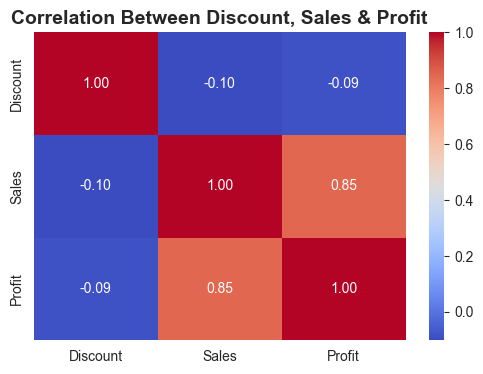

In [42]:
plt.figure(figsize=(6,4))
sns.heatmap(df_filtered[['Discount','Sales','Profit']].corr(), 
            annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Discount, Sales & Profit", fontsize=14, fontweight='bold')
plt.show()

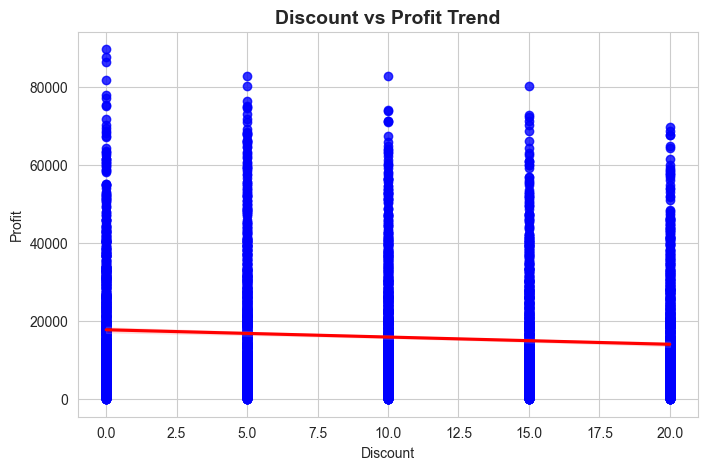

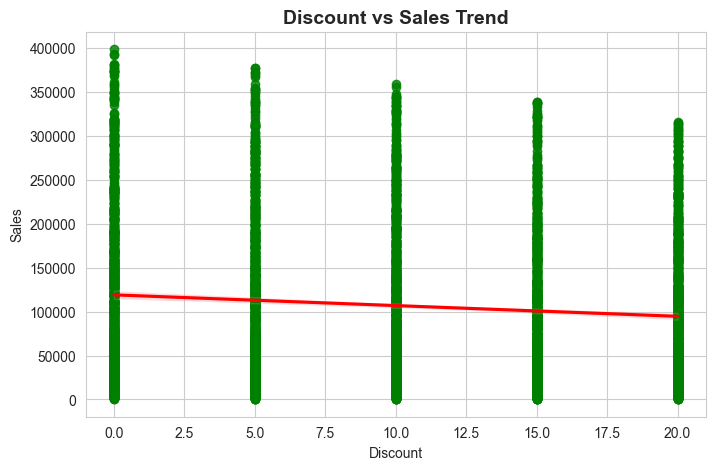

In [43]:
plt.figure(figsize=(8,5))
sns.regplot(x='Discount', y='Profit', data=df, scatter_kws={'color':'blue'}, line_kws={'color':'red'})
plt.title("Discount vs Profit Trend", fontsize=14, fontweight='bold')
plt.show()

plt.figure(figsize=(8,5))
sns.regplot(x='Discount', y='Sales', data=df, scatter_kws={'color':'green'}, line_kws={'color':'red'})
plt.title("Discount vs Sales Trend", fontsize=14, fontweight='bold')
plt.show()

In [47]:
region_eff = df.groupby(['Region', 'Discount']).agg({
    'Sales': 'mean',
    'Profit': 'mean',
    'Quantity': 'mean'
}).reset_index()

region_eff.sort_values(['Region', 'Discount'])

,Region,Discount,Sales,Profit,Quantity
0,East,0,118978.727273,16653.103223,2.942149
1,East,5,117535.450189,18722.070076,3.200758
2,East,10,113242.395000,16604.972708,3.158333
3,East,15,98900.412351,15662.200916,2.928287
4,East,20,92614.860232,14067.470116,2.984556
5,North,0,120698.245614,17319.939298,2.986842
6,North,5,120061.496923,18701.621154,3.188462
7,North,10,111788.556818,17072.213977,3.083333
8,North,15,103928.202632,15140.954286,2.996241
9,North,20,102540.651852,14803.993852,3.066667


In [48]:
category_eff = df.groupby(['Category', 'Discount']).agg({
    'Sales': 'mean',
    'Profit': 'mean',
    'Quantity': 'mean'
}).reset_index()

category_eff.sort_values(['Category', 'Discount'])

,Category,Discount,Sales,Profit,Quantity
0,Beauty,0,141150.235955,20003.960674,3.123596
1,Beauty,5,109118.429439,16715.229252,3.000000
2,Beauty,10,114935.910000,15009.875000,3.122222
3,Beauty,15,104786.252247,15572.126629,3.134831
4,Beauty,20,81119.510588,10679.364941,2.776471
5,Books,0,123531.622951,18348.621230,3.147541
6,Books,5,113096.464607,16660.500562,3.168539
7,Books,10,114503.947059,16853.636667,3.107843
8,Books,15,86031.310360,12565.081351,2.783784
9,Books,20,82378.092308,11934.249808,2.682692


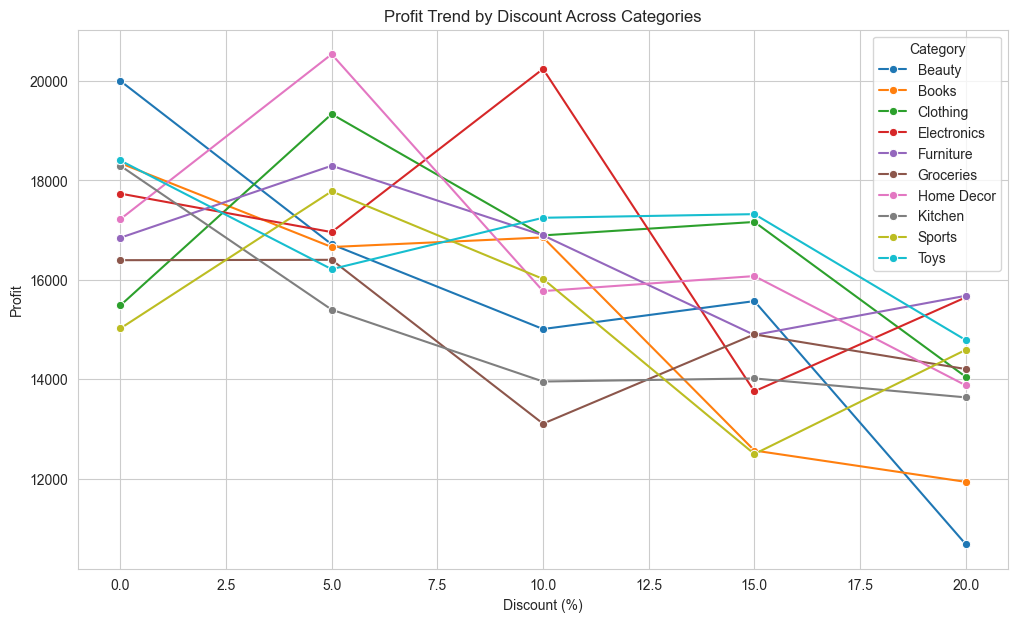

In [59]:
plt.figure(figsize=(12, 7))  # width, height in inches

sns.lineplot(
    data=category_eff,
    x='Discount',
    y='Profit',
    hue='Category',
    marker='o'
)

plt.title("Profit Trend by Discount Across Categories")
plt.xlabel("Discount (%)")
plt.ylabel("Profit")

plt.show()

In [60]:
threshold = df.groupby('Discount').agg({
    'Profit': 'mean',
    'Sales': 'mean'
}).reset_index()

threshold

,Discount,Profit,Sales
0,0,17301.211122,117340.715431
1,5,17442.927331,114617.711759
2,10,16237.786882,108404.868529
3,15,14828.028087,98967.904730
4,20,13951.468217,94618.464251


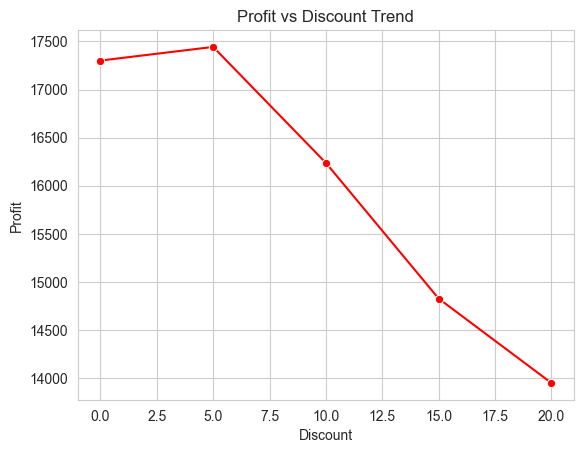

In [62]:
sns.lineplot(data=threshold, x='Discount', y='Profit', marker='o', color='red')
plt.title("Profit vs Discount Trend")
plt.show()